In [3]:
from pathlib import Path

IMAGES_PATH = Path("../resources/cloud-images/NASA_GLOBE_CD/downloaded_images")

def index_labeled_images(images_path=IMAGES_PATH):
    cloud_labels = []
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images

    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        count = 0
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            if count > 3000:
                break
            labeled_images[img_path.name] = {
                "label": cloud_dir.name,
                "path": str(img_path)
            }
            count += 1

    return labeled_images, cloud_labels

In [4]:
labeled_images, cloud_labels = index_labeled_images()

ValueError: not enough values to unpack (expected 2, got 0)

In [7]:
print(len(labeled_images))

NameError: name 'labeled_images' is not defined

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tqdm.auto import tqdm

def extract_labels(labeled_images):
    import os  # Ensure os is imported for path validation
    images = []
    labels = []
    for (i, image_name) in tqdm(enumerate(labeled_images), total=len(labeled_images)):
        path = labeled_images[image_name]['path']

        # Check if the file exists before attempting to read
        if not os.path.exists(path):
            print(f"Error: File does not exist at path: {path}")
            continue

        # Attempt to read the image
        image = cv2.imread(path)
        if image is None:
            print(f"Error: Unable to read image at path: {path}")
            continue

        try:
            # Convert to grayscale and resize
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            image = cv2.resize(image, (64, 64))
            images.append(image)

            # Append the label
            label = labeled_images[image_name]['label']
            labels.append(label)
        except Exception as e:
            print(f"Error processing image {image_name}: {e}")
            continue

    return np.array(images), np.array(labels)

In [ ]:
images, labels = extract_labels(labeled_images)

100%|██████████| 30559/30559 [04:14<00:00, 120.23it/s]


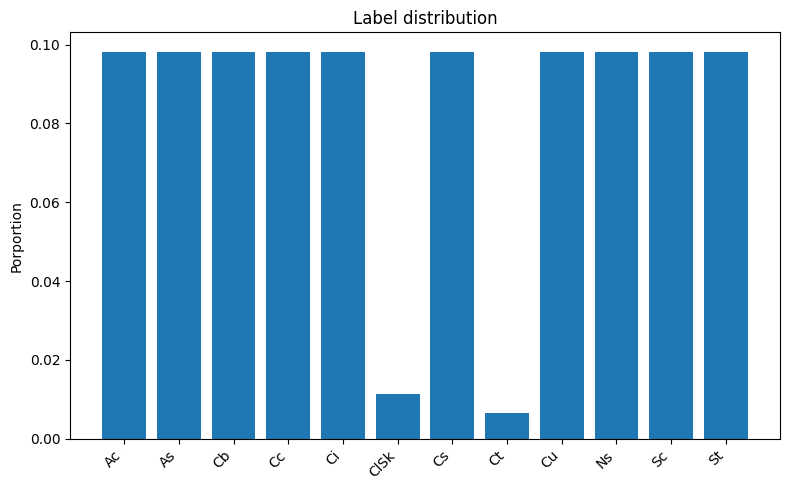

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# labels must be a 1D array or list of class names
label_counts = Counter(labels)
classes = list(label_counts.keys())
counts = np.array(list(label_counts.values()))
props = counts / counts.sum()

plt.figure(figsize=(8, 5))
plt.bar(classes, props)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Porportion")
plt.title("Label distribution")
plt.tight_layout()
plt.show()

In [ ]:
print(props)

[0.09820348 0.09820348 0.09820348 0.09820348 0.09820348 0.01142053
 0.09820348 0.00654472 0.09820348 0.09820348 0.09820348 0.09820348]


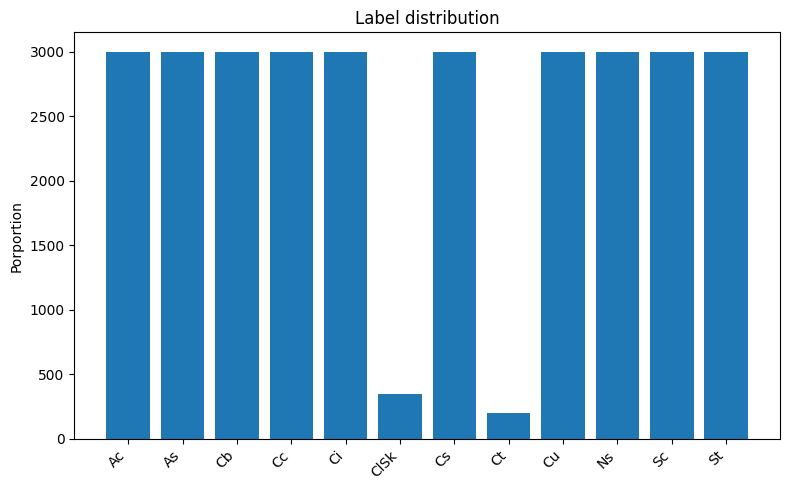

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# labels must be a 1D array or list of class names
label_counts = Counter(labels)
classes = list(label_counts.keys())
counts = np.array(list(label_counts.values()))

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Porportion")
plt.title("Label distribution")
plt.tight_layout()
plt.show()

In [ ]:
print(counts)

[3001 3001 3001 3001 3001  349 3001  200 3001 3001 3001 3001]


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

ordinal_encoder = LabelEncoder()
labels_encoded = ordinal_encoder.fit_transform(labels)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(images, labels_encoded))

X_train, X_test = images[train_idx], images[test_idx]
y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)

train: (24447, 64, 64) (24447,)
test:  (6112, 64, 64) (6112,)


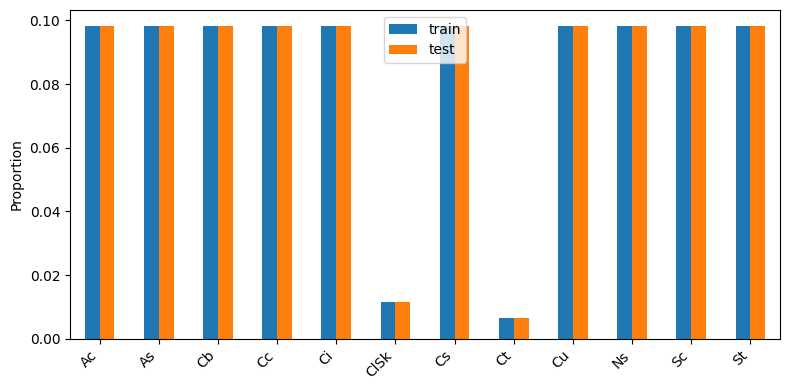

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

train_props = pd.Series(ordinal_encoder.inverse_transform(y_train)).value_counts(normalize=True)
test_props  = pd.Series(ordinal_encoder.inverse_transform(y_test)).value_counts(normalize=True)

df = pd.DataFrame({"train": train_props, "test": test_props}).fillna(0).reindex(ordinal_encoder.classes_)

df.plot(kind="bar", figsize=(8,4))
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

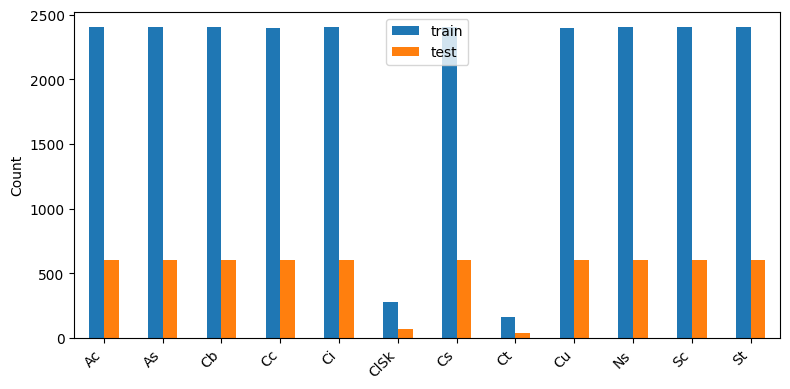

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# inverse_transform returns shape (n_samples, 1) for many encoders -> flatten to 1D
train_labels = ordinal_encoder.inverse_transform(y_train).ravel()
test_labels  = ordinal_encoder.inverse_transform(y_test).ravel()

train_counts = pd.Series(train_labels).value_counts()        # <- absolute counts
test_counts  = pd.Series(test_labels).value_counts()

df = (pd.DataFrame({"train": train_counts, "test": test_counts}).fillna(0).astype(int).reindex(ordinal_encoder.classes_, fill_value=0))

ax = df.plot(kind="bar", figsize=(8,4))
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
print(X_train[0])
print(type(y_train))

[[174 172 168 ... 166 164 164]
 [174 172 170 ... 166 164 166]
 [170 169 170 ... 166 164 164]
 ...
 [186 186 184 ... 178 175 178]
 [186 188 186 ... 176 178 180]
 [188 186 188 ... 176 180 176]]
<class 'numpy.ndarray'>


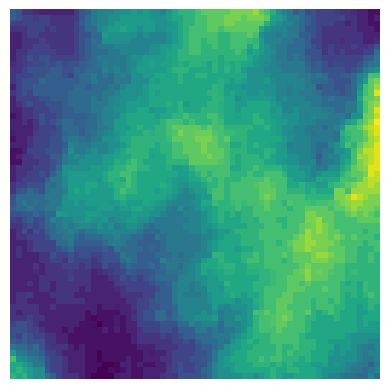

In [ ]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
import torchvision.transforms as transforms

img_tensor = torch.from_numpy(X_train[0])

def plot_image(image):
    plt.imshow(image)
    plt.axis("off")

plot_image(img_tensor)
plt.show()

In [ ]:
# augmentation

import torch
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

def color_jitter_if_rgb(x):
    return T.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.02)(x) if x.ndim == 3 and x.shape[0] == 3 else x

IMG_SIZE = (64, 64)
MAX_FRAC = 0.14

# translation with black borders
border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

# translation with wrap/repeat
wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]), int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),  # dy
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]), int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),  # dx
    ),
    dims=(-2, -1),
))

# stacked pipeline
stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20,
        scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR,
        fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
    # T.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.02),
])

# one of pipeline
one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([
        T.RandomHorizontalFlip(p=1.0),
        T.RandomVerticalFlip(p=1.0),
    ]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
    # T.ColorJitter(brightness=0.20),
    # T.ColorJitter(contrast=0.20),
    # T.ColorJitter(saturation=0.15),
])

# alternating between modes
augmentation_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
])

In [ ]:
print(img_tensor.shape, img_tensor.dtype)

torch.Size([64, 64]) torch.uint8


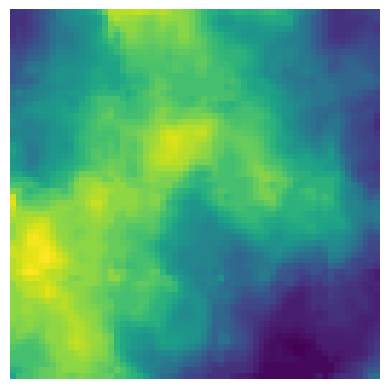

In [ ]:
augmented_img = augmentation_transform(img_tensor.unsqueeze(0))
plt.imshow(augmented_img.squeeze(0))  # (64,64)
plt.axis("off")
plt.show()


In [ ]:
print(classes[5])
print(classes[7])

print(classes)
print(train_counts["ClSk"])
print(train_counts["Ct"])

ClSk
Ct
[np.str_('Ac'), np.str_('As'), np.str_('Cb'), np.str_('Cc'), np.str_('Ci'), np.str_('ClSk'), np.str_('Cs'), np.str_('Ct'), np.str_('Cu'), np.str_('Ns'), np.str_('Sc'), np.str_('St')]
279
160


In [ ]:
import numpy

train_count = 0.8 * 3000

clsk_multiple = train_count // train_counts["ClSk"]
ct_multiple = train_count // train_counts["Ct"]

print(clsk_multiple, ct_multiple)



train_counts[5]

y_train_augmented_images = []
X_train_augmented_images = []

for i in range(len(y_train)):
    if y_train[i] == 5:
        for j in range(int(clsk_multiple) - 1):
            img_torch = torch.from_numpy(X_train[i])
            augmented_img = augmentation_transform(img_tensor.unsqueeze(0))
            squeezed_img = augmented_img.squeeze(0)
            X_train_augmented_images.append(squeezed_img.numpy())
            y_train_augmented_images.append(5)

    if y_train[i] == 7:
        for j in range(int(ct_multiple) - 1):
            img_torch = torch.from_numpy(X_train[i])
            augmented_img = augmentation_transform(img_tensor.unsqueeze(0))
            squeezed_img = augmented_img.squeeze(0)
            X_train_augmented_images.append(squeezed_img.numpy())
            y_train_augmented_images.append(7)


8.0 15.0


/var/folders/n5/g_2w_9497mb0cvvg5_p2v3km0000gn/T/ipykernel_29097/1124503045.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  train_counts[5]


In [ ]:
print(len(y_train_augmented_images))

4193


In [ ]:
y_train_with_augmented_images = np.concatenate((y_train, y_train_augmented_images))
X_train_with_augmented_images = np.concatenate((X_train, X_train_augmented_images))

In [ ]:
print(y_train_with_augmented_images.shape, X_train_with_augmented_images.shape)


(28640,) (28640, 64, 64)


In [ ]:
import numpy as np

# Create a permuted list of indices
indices = np.random.permutation(len(y_train_with_augmented_images))

# Reorder both arrays using those indices
X_train_with_augmented_images = X_train_with_augmented_images[indices]
y_train_with_augmented_images = y_train_with_augmented_images[indices]


[[192. 194. 198. ... 184. 180. 177.]
 [ 20. 202. 133. ... 183. 179. 177.]
 [ 42.  46.  11. ... 182. 178. 177.]
 ...
 [ 14.  16. 117. ... 104.  49. 135.]
 [  4.  14.   9. ... 155.  79.  54.]
 [  9.  14. 140. ... 118.  21. 130.]]
11


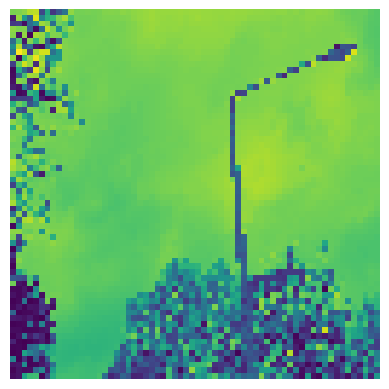

In [ ]:
print(X_train_with_augmented_images[2])

plot_image(X_train_with_augmented_images[2])
print(y_train_with_augmented_images[2])

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


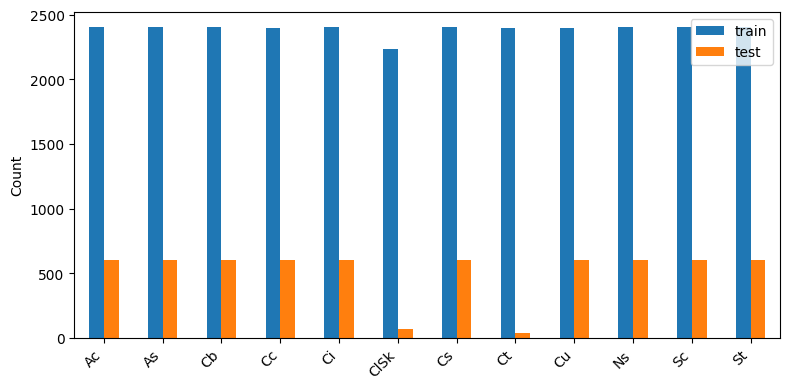

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ytr = pd.Series(y_train_with_augmented_images).to_numpy().reshape(-1, 1)
yte = pd.Series(y_test).to_numpy().reshape(-1, 1)

train_labels = ordinal_encoder.inverse_transform(ytr).ravel()
test_labels  = ordinal_encoder.inverse_transform(yte).ravel()

train_counts = pd.Series(train_labels).value_counts()
test_counts  = pd.Series(test_labels).value_counts()

df = (pd.DataFrame({"train": train_counts, "test": test_counts})
        .reindex(ordinal_encoder.classes_, fill_value=0)
        .astype(int))

ax = df.plot(kind="bar", figsize=(8,4))
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
print("train:", X_train_with_augmented_images.shape, y_train_with_augmented_images.shape)
print("test: ", X_test.shape, y_test.shape)

train: (28640, 64, 64) (28640,)
test:  (6112, 64, 64) (6112,)


In [ ]:
X_train_flat = X_train_with_augmented_images.reshape(len(X_train_with_augmented_images), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

In [ ]:
print(X_train_flat.shape)
print(X_test_flat.shape)

(28640, 4096)
(6112, 4096)


In [ ]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def display_clf_scores(labels, predictions):
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)


In [ ]:
from typing import Dict, Any
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


def get_default_classifiers(random_state: int = 42) -> Dict[str, Any]:
    """
    Return a dictionary of main classification models (some with scaling).
    """
    return {
        "gaussian_nb": GaussianNB(),
        "log_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=random_state))
        ]),
        "linear_svc": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SGDClassifier(loss="hinge", random_state=random_state))
        ]),
        "svc_rbf": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", probability=True, random_state=random_state))
        ]),
        "knn": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "decision_tree": DecisionTreeClassifier(random_state=random_state),
        "random_forest": RandomForestClassifier(random_state=random_state),
        "gradient_boosting": GradientBoostingClassifier(random_state=random_state,
                                                        n_estimators=150,
                                                        learning_rate=0.1,
                                                        max_depth=3,
                                                        subsample=0.7
                                                        ),
        "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=random_state),
        "mlp": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(max_iter=500, random_state=random_state))
        ])
    }


def evaluate_classifiers(X, y, scoring: str = "f1_macro", cv: int = 3,
                         n_jobs: int = -1, random_state: int = 42,
                         verbose: int = 1
) -> pd.DataFrame:
    """
    Evaluate many classification models with default hyperparameters.
    Returns a sorted dataframe of cross-validation results.
    """
    classifiers = get_default_classifiers(random_state)
    cv_obj = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    results = []

    for name, clf in tqdm(classifiers.items(), total=len(classifiers.items())):
        if verbose:
            print(f"\nEvaluating model: {name}")

        t0 = time.perf_counter()

        scores = cross_val_score(
            clf, X, y,
            scoring=scoring,
            cv=cv_obj,
            n_jobs=n_jobs
        )

        t1 = time.perf_counter()

        results.append({
            "model": name,
            "mean_score": np.mean(scores),
            "std_score": np.std(scores),
            "time_elapsed": t1 - t0
        })

    return pd.DataFrame(results).sort_values("mean_score", ascending=False)


In [ ]:
results = evaluate_classifiers(X_train_flat, y_train_with_augmented_images, scoring="f1_macro", cv=5)
print(results)


  0%|          | 0/10 [00:00<?, ?it/s]


Evaluating model: gaussian_nb


 10%|█         | 1/10 [00:04<00:40,  4.55s/it]


Evaluating model: log_reg


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely 

...


Evaluating model: hist_gradient_boosting


 90%|█████████ | 9/10 [4:59:20<55:33, 3333.96s/it]  


Evaluating model: mlp


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: 

                    model  mean_score  std_score  time_elapsed
6           random_forest    0.366778   0.003886     68.527072
8  hist_gradient_boosting    0.365726   0.003557    306.005437
7       gradient_boosting    0.331421   0.003596  13907.824863
4                     knn    0.289423   0.005867     11.544548
3                 svc_rbf    0.287163   0.004170   2870.353336
5           decision_tree    0.272435   0.002794     66.676688
9                     mlp    0.259258   0.005436     45.961913
1                 log_reg    0.223195   0.005131    112.299023
0             gaussian_nb    0.191506   0.003964      4.548103
2              linear_svc    0.181236   0.010683    612.591920
